# Augmented Dickey-Fuller Test for Climate Data Stationarity

This notebook performs the Augmented Dickey-Fuller (ADF) test to check for trends/non-stationarity in climate time series:

- **PDSI** - Per state
- **SPI** (SPI_1m, SPI_3m, SPI_7d) - Per state
- **TMAX, TMIN, AWND** - Per state
- **CO2** - Global (single series)

Additionally, we test climate variables during **planting** and **harvesting** sessions for corn, soybean, and wheat.

## ADF Test Interpretation
- Null Hypothesis (H0): Series has a unit root (non-stationary, trend exists)
- Alternative Hypothesis (H1): Series is stationary (no unit root)
- If p-value < 0.05: Reject H0 → Series is stationary (no trend)
- If p-value ≥ 0.05: Fail to reject H0 → Series is non-stationary (trend exists)

## Imports

In [46]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.util.path import DATA_DIR
from src.dataset.climate.crop_seasonal import crop_season_flag
from src.dataset.climate.pdsi import build_state_pdsi_frame

## Settings

In [47]:
# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Paths
PALMER_DIR = DATA_DIR / 'climate' / 'palmer'
NOAA_WEEKLY = DATA_DIR / 'climate' / 'noaa_weekly.csv'
SPI_WEEKLY = DATA_DIR / 'climate' / 'spi_weekly_multiscale.csv'
CO2_WEEKLY = DATA_DIR / 'climate' / 'co2_weekly_mlo.csv'

# ADF test significance level
ALPHA = 0.05

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)

## Helper Functions

In [48]:
def run_adf_test(series, series_name):
    """
    Run Augmented Dickey-Fuller test on a time series.
    
    Returns:
        dict with test results
    """
    clean_series = series.dropna()
    
    if len(clean_series) < 10:
        return {
            'series': series_name,
            'n_obs': len(clean_series),
            'adf_statistic': np.nan,
            'p_value': np.nan,
            'critical_1%': np.nan,
            'critical_5%': np.nan,
            'critical_10%': np.nan,
            'stationary': 'Insufficient data',
            'trend_exists': 'Unknown'
        }
    
    try:
        result = adfuller(clean_series, autolag='AIC')
        
        adf_stat = result[0]
        p_value = result[1]
        critical_values = result[4]
        
        is_stationary = p_value < ALPHA
        trend_exists = not is_stationary
        
        return {
            'series': series_name,
            'n_obs': len(clean_series),
            'adf_statistic': adf_stat,
            'p_value': p_value,
            'critical_1%': critical_values['1%'],
            'critical_5%': critical_values['5%'],
            'critical_10%': critical_values['10%'],
            'stationary': 'Yes' if is_stationary else 'No',
            'trend_exists': 'Yes' if trend_exists else 'No'
        }
    except Exception as e:
        return {
            'series': series_name,
            'n_obs': len(clean_series),
            'adf_statistic': np.nan,
            'p_value': np.nan,
            'critical_1%': np.nan,
            'critical_5%': np.nan,
            'critical_10%': np.nan,
            'stationary': f'Error: {str(e)}',
            'trend_exists': 'Unknown'
        }

def summarize_adf_results(results_df):
    """
    Summarize ADF test results.
    """
    print("\n" + "="*100)
    print("ADF TEST SUMMARY")
    print("="*100)
    
    total = len(results_df)
    stationary = (results_df['stationary'] == 'Yes').sum()
    non_stationary = (results_df['stationary'] == 'No').sum()
    
    print(f"\nTotal series tested: {total}")
    print(f"Stationary (no trend): {stationary} ({stationary/total*100:.1f}%)")
    print(f"Non-stationary (trend exists): {non_stationary} ({non_stationary/total*100:.1f}%)")
    
    print(f"\nMean p-value: {results_df['p_value'].mean():.4f}")
    print(f"Median p-value: {results_df['p_value'].median():.4f}")

## 1. PDSI - Per State Analysis

In [49]:
print("Loading PDSI data...")
pdsi_data = build_state_pdsi_frame(PALMER_DIR)

print(f"PDSI data shape: {pdsi_data.shape}")
print(f"Number of states: {pdsi_data['state'].nunique()}")
print(f"Date range: {pdsi_data['date'].min()} to {pdsi_data['date'].max()}")
pdsi_data.head()

Loading PDSI data...
PDSI data shape: (50880, 3)
Number of states: 48
Date range: 2004-12-27 00:00:00 to 2025-12-08 00:00:00


,date,state,pdsi
0,2004-12-27,Alabama,2.432500
1,2004-12-27,Arizona,1.682857
2,2004-12-27,Arkansas,0.648889
3,2004-12-27,California,1.572857
4,2004-12-27,Colorado,0.412000


In [50]:
print("\nRunning ADF tests for PDSI per state...")
pdsi_results = []

for state in sorted(pdsi_data['state'].unique()):
    state_data = pdsi_data[pdsi_data['state'] == state].sort_values('date')
    result = run_adf_test(state_data['pdsi'], f'PDSI - {state}')
    pdsi_results.append(result)
    
pdsi_results_df = pd.DataFrame(pdsi_results)

print("\n" + "="*100)
print("PDSI ADF NON-STATIONARY RESULTS (Per State)")
print("="*100)
pdsi_trend_df = pdsi_results_df[pdsi_results_df['trend_exists'] == 'Yes']
if len(pdsi_trend_df) > 0:
    print(pdsi_trend_df.to_string(index=False))
else:
    print("No non-stationary series with trend found.")

summarize_adf_results(pdsi_results_df)


Running ADF tests for PDSI per state...

PDSI ADF NON-STATIONARY RESULTS (Per State)
             series  n_obs  adf_statistic  p_value  critical_1%  critical_5%  critical_10% stationary trend_exists
    PDSI - Nebraska   1060      -2.316480 0.166708    -3.436558    -2.864281     -2.568229         No          Yes
      PDSI - Nevada   1060      -2.819059 0.055602    -3.436546    -2.864276     -2.568227         No          Yes
PDSI - South Dakota   1060      -2.631608 0.086639    -3.436540    -2.864273     -2.568225         No          Yes

ADF TEST SUMMARY

Total series tested: 48
Stationary (no trend): 45 (93.8%)
Non-stationary (trend exists): 3 (6.2%)

Mean p-value: 0.0101
Median p-value: 0.0008


## 2. SPI - Per State Analysis

In [51]:
print("\nLoading SPI data...")
spi_data = pd.read_csv(SPI_WEEKLY)
spi_data['week_date'] = pd.to_datetime(spi_data['week_date'])

print(f"SPI data shape: {spi_data.shape}")
print(f"Number of states: {spi_data['state'].nunique()}")
print(f"Date range: {spi_data['week_date'].min()} to {spi_data['week_date'].max()}")
print(f"\nSPI columns: {[col for col in spi_data.columns if 'SPI' in col]}")
spi_data.sample(5)


Loading SPI data...
SPI data shape: (44400, 9)
Number of states: 50
Date range: 2008-12-29 00:00:00 to 2025-12-29 00:00:00

SPI columns: ['SPI_7d', 'SPI_1m', 'SPI_2m', 'SPI_3m', 'SPI_6m', 'SPI_12m']


,state,week_date,date,SPI_7d,SPI_1m,SPI_2m,SPI_3m,SPI_6m,SPI_12m
28812,NV,2016-08-01,2016-08-07,0.014276,-1.407752,-1.326741,-1.291851,0.040642,0.756835
8915,HI,2009-08-31,2009-09-06,-0.433194,-0.202466,-0.494597,-0.937230,-1.233788,NaN
13800,KS,2018-03-12,2018-03-18,-0.977703,-1.221410,-1.874922,-2.220955,-1.692198,0.156486
38755,UT,2019-12-09,2019-12-15,1.057712,1.861589,0.954208,0.421745,-0.614972,1.315625
18432,ME,2021-11-15,2021-11-21,-0.082575,1.160186,0.796028,0.915249,0.848449,-0.001363


In [52]:
print("\nRunning ADF tests for SPI per state...")
spi_results = []
spi_columns = ['SPI_1m', 'SPI_3m', 'SPI_7d']

for state in sorted(spi_data['state'].unique()):
    state_data = spi_data[spi_data['state'] == state].sort_values('week_date')
    
    for spi_col in spi_columns:
        if spi_col in state_data.columns:
            result = run_adf_test(state_data[spi_col], f'{spi_col} - {state}')
            spi_results.append(result)

spi_results_df = pd.DataFrame(spi_results)

print("\n" + "="*100)
print("SPI ADF NON-STATIONARY RESULTS (Per State)")
print("="*100)
spi_trend_df = spi_results_df[spi_results_df['trend_exists'] == 'Yes']
if len(spi_trend_df) > 0:
    print(spi_trend_df.to_string(index=False))
else:
    print("No non-stationary series with trend found.")

summarize_adf_results(spi_results_df)


Running ADF tests for SPI per state...

SPI ADF NON-STATIONARY RESULTS (Per State)
No non-stationary series with trend found.

ADF TEST SUMMARY

Total series tested: 150
Stationary (no trend): 150 (100.0%)
Non-stationary (trend exists): 0 (0.0%)

Mean p-value: 0.0000
Median p-value: 0.0000


## 3. TMAX, TMIN, AWND - Per State Analysis

In [53]:
print("\nLoading NOAA weekly data...")
noaa_data = pd.read_csv(NOAA_WEEKLY)
noaa_data['date'] = pd.to_datetime(noaa_data['date'])

print(f"NOAA data shape: {noaa_data.shape}")
print(f"Number of states: {noaa_data['state'].nunique()}")
print(f"Date range: {noaa_data['date'].min()} to {noaa_data['date'].max()}")
print(f"\nColumns: {noaa_data.columns.tolist()}")
noaa_data.head()


Loading NOAA weekly data...
NOAA data shape: (94000, 6)
Number of states: 50
Date range: 1990-01-01 00:00:00 to 2025-12-29 00:00:00

Columns: ['state', 'date', 'PRCP', 'TMAX', 'TMIN', 'AWND']


,state,date,PRCP,TMAX,TMIN,AWND
0,AK,1990-01-01,NaN,-11.266597,-18.090278,4.023571
1,AK,1990-01-08,NaN,-8.162190,-17.025771,4.218299
2,AK,1990-01-15,NaN,-1.904951,-8.212460,4.729286
3,AK,1990-01-22,NaN,-10.639633,-18.063999,3.094218
4,AK,1990-01-29,NaN,-15.823874,-24.261170,4.513831


In [54]:
# Run ADF test for each state's TMAX, TMIN, AWND
print("\nRunning ADF tests for TMAX, TMIN, AWND per state...")
noaa_results = []
noaa_columns = ['TMAX', 'TMIN', 'AWND']

for state in sorted(noaa_data['state'].unique()):
    state_data = noaa_data[noaa_data['state'] == state].sort_values('date')
    
    for col in noaa_columns:
        if col in state_data.columns:
            result = run_adf_test(state_data[col], f'{col} - {state}')
            noaa_results.append(result)

noaa_results_df = pd.DataFrame(noaa_results)

print("\n" + "="*100)
print("TMAX, TMIN, AWND ADF NON-STATIONARY RESULTS (Per State)")
print("="*100)
noaa_trend_df = noaa_results_df[noaa_results_df['trend_exists'] == 'Yes']
if len(noaa_trend_df) > 0:
    print(noaa_trend_df.to_string(index=False))
else:
    print("No non-stationary series with trend found.")

summarize_adf_results(noaa_results_df)


Running ADF tests for TMAX, TMIN, AWND per state...

TMAX, TMIN, AWND ADF NON-STATIONARY RESULTS (Per State)
No non-stationary series with trend found.

ADF TEST SUMMARY

Total series tested: 150
Stationary (no trend): 150 (100.0%)
Non-stationary (trend exists): 0 (0.0%)

Mean p-value: 0.0000
Median p-value: 0.0000


## 4. CO2 - Global Analysis

In [55]:
print("\nLoading CO2 data...")
co2_data = pd.read_csv(CO2_WEEKLY)

# Check column names
print(f"CO2 data shape: {co2_data.shape}")
print(f"Columns: {co2_data.columns.tolist()}")
co2_data.head(10)


Loading CO2 data...
CO2 data shape: (886, 3)
Columns: ['Unnamed: 0', 'date', 'co2_molfrac_ppm']


,Unnamed: 0,date,co2_molfrac_ppm
0,0,2008-12-29,386.63
1,1,2009-01-05,387.24
2,2,2009-01-12,387.37
3,3,2009-01-19,387.74
4,4,2009-01-26,387.25
5,5,2009-02-02,387.16
6,6,2009-02-09,387.84
7,7,2009-02-16,388.45
8,8,2009-02-23,389.30
9,9,2009-03-02,389.03


In [56]:
date_col = [col for col in co2_data.columns if 'date' in col.lower()][0] if any('date' in col.lower() for col in co2_data.columns) else co2_data.columns[0]
co2_col = [col for col in co2_data.columns if 'co2' in col.lower() or 'mole' in col.lower()][0] if any('co2' in col.lower() or 'mole' in col.lower() for col in co2_data.columns) else co2_data.columns[1]

print(f"\nUsing date column: {date_col}")
print(f"Using CO2 column: {co2_col}")

co2_data[date_col] = pd.to_datetime(co2_data[date_col], errors='coerce')
co2_data = co2_data.sort_values(date_col).dropna(subset=[date_col])

print(f"\nDate range: {co2_data[date_col].min()} to {co2_data[date_col].max()}")
print(f"Number of observations: {len(co2_data)}")


Using date column: date
Using CO2 column: co2_molfrac_ppm

Date range: 2008-12-29 00:00:00 to 2025-12-22 00:00:00
Number of observations: 886


In [57]:
print("\nRunning ADF test for CO2 (global)...")
co2_result = run_adf_test(co2_data[co2_col], 'CO2 (Global)')
co2_results_df = pd.DataFrame([co2_result])

print("\n" + "="*100)
print("CO2 ADF NON-STATIONARY RESULTS (Global)")
print("="*100)
co2_trend_df = co2_results_df[co2_results_df['trend_exists'] == 'Yes']
if len(co2_trend_df) > 0:
    print(co2_trend_df.to_string(index=False))
else:
    print("No non-stationary series with trend found.")


Running ADF test for CO2 (global)...

CO2 ADF NON-STATIONARY RESULTS (Global)
      series  n_obs  adf_statistic  p_value  critical_1%  critical_5%  critical_10% stationary trend_exists
CO2 (Global)    886        -0.6675 0.854989    -3.437889    -2.864868     -2.568542         No          Yes


## Combined Summary

In [58]:
all_results = pd.concat([
    pdsi_results_df.assign(category='PDSI'),
    spi_results_df.assign(category='SPI'),
    noaa_results_df.assign(category='NOAA'),
    co2_results_df.assign(category='CO2')
], ignore_index=True)

print("\n" + "="*100)
print("OVERALL ADF TEST SUMMARY")
print("="*100)

for category in ['PDSI', 'SPI', 'NOAA', 'CO2']:
    cat_data = all_results[all_results['category'] == category]
    total = len(cat_data)
    stationary = (cat_data['stationary'] == 'Yes').sum()
    non_stationary = (cat_data['stationary'] == 'No').sum()
    
    print(f"\n{category}:")
    print(f"  Total series: {total}")
    print(f"  Stationary (no trend): {stationary} ({stationary/total*100:.1f}%)")
    print(f"  Non-stationary (trend exists): {non_stationary} ({non_stationary/total*100:.1f}%)")
    print(f"  Mean p-value: {cat_data['p_value'].mean():.4f}")


OVERALL ADF TEST SUMMARY

PDSI:
  Total series: 48
  Stationary (no trend): 45 (93.8%)
  Non-stationary (trend exists): 3 (6.2%)
  Mean p-value: 0.0101

SPI:
  Total series: 150
  Stationary (no trend): 150 (100.0%)
  Non-stationary (trend exists): 0 (0.0%)
  Mean p-value: 0.0000

NOAA:
  Total series: 150
  Stationary (no trend): 150 (100.0%)
  Non-stationary (trend exists): 0 (0.0%)
  Mean p-value: 0.0000

CO2:
  Total series: 1
  Stationary (no trend): 0 (0.0%)
  Non-stationary (trend exists): 1 (100.0%)
  Mean p-value: 0.8550


## Visualization: P-value Distribution

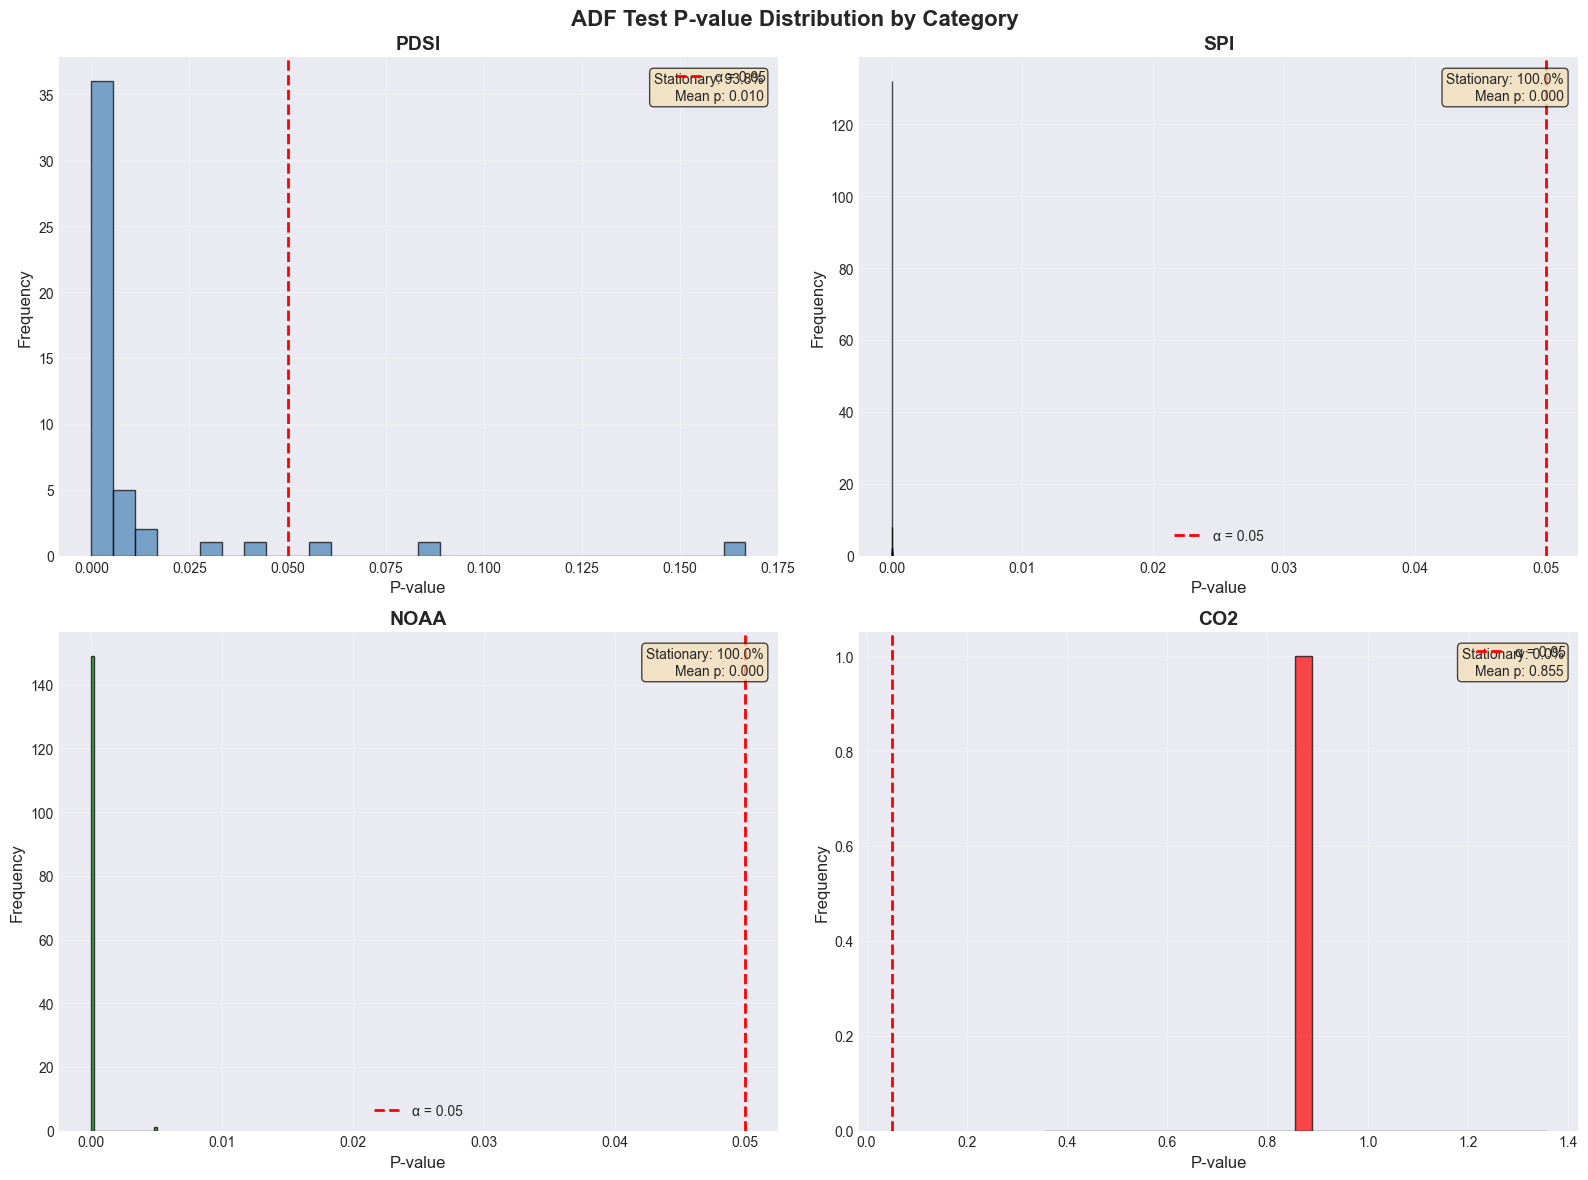

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ADF Test P-value Distribution by Category', fontsize=16, fontweight='bold')

categories = ['PDSI', 'SPI', 'NOAA', 'CO2']
colors = ['steelblue', 'orange', 'green', 'red']

for idx, (category, color) in enumerate(zip(categories, colors)):
    ax = axes[idx // 2, idx % 2]
    cat_data = all_results[all_results['category'] == category]
    
    # Plot histogram
    ax.hist(cat_data['p_value'].dropna(), bins=30, color=color, alpha=0.7, edgecolor='black')
    
    # Add significance line
    ax.axvline(x=ALPHA, color='red', linestyle='--', linewidth=2, label=f'α = {ALPHA}')
    
    ax.set_xlabel('P-value', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{category}', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    stationary_pct = (cat_data['stationary'] == 'Yes').sum() / len(cat_data) * 100
    stats_text = f"Stationary: {stationary_pct:.1f}%\nMean p: {cat_data['p_value'].mean():.3f}"
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7), fontsize=10)

plt.tight_layout()
plt.show()

## 7. Seasonal Analysis - Planting & Harvesting Sessions

Test climate variables during planting and harvesting periods for corn, soybean, and wheat.

In [60]:
# Load NOAA weekly data for seasonal filtering
noaa_df = pd.read_csv(NOAA_WEEKLY, parse_dates=['date'])
noaa_df['week_of_year'] = noaa_df['date'].dt.isocalendar().week

print(f"NOAA data shape: {noaa_df.shape}")
print(f"Date range: {noaa_df['date'].min()} to {noaa_df['date'].max()}")
print(f"\nStates: {sorted(noaa_df['state'].unique())}")
print(f"Variables: {[c for c in noaa_df.columns if c not in ['date', 'state', 'week_of_year']]}")

NOAA data shape: (94000, 7)
Date range: 1990-01-01 00:00:00 to 2025-12-29 00:00:00

States: ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']
Variables: ['PRCP', 'TMAX', 'TMIN', 'AWND']


In [61]:
# Define crops and climate variables to test
CROPS = ['corn', 'soybean', 'wheat']
CLIMATE_VARS = ['TMAX', 'TMIN', 'AWND']
SESSIONS = ['planting', 'harvesting']

seasonal_results = []

for crop in CROPS:
    print(f"\nProcessing {crop.upper()}...")
    
    # Add seasonal flags
    noaa_df['is_planting'] = noaa_df['week_of_year'].apply(
        lambda w: crop_season_flag(w, crop)['is_planting_week']
    )
    noaa_df['is_harvesting'] = noaa_df['week_of_year'].apply(
        lambda w: crop_season_flag(w, crop)['is_harvesting_week']
    )
    
    for session in SESSIONS:
        # Filter data for this session
        session_col = f'is_{session}'
        session_data = noaa_df[noaa_df[session_col] == 1].copy()
        
        # Test each state and climate variable
        for state in sorted(noaa_df['state'].unique()):
            state_data = session_data[session_data['state'] == state]
            
            for var in CLIMATE_VARS:
                if var in state_data.columns:
                    series = state_data[var]
                    series_name = f"{crop}_{session}_{state}_{var}"
                    
                    result = run_adf_test(series, series_name)
                    result['crop'] = crop
                    result['session'] = session
                    result['state'] = state
                    result['variable'] = var
                    result['category'] = f'{crop.capitalize()} {session.capitalize()}'
                    
                    # Only log non-stationary results (with trends)
                    if result['trend_exists'] == 'Yes':
                        print(f"  ⚠️  TREND DETECTED: {series_name} (p={result['p_value']:.4f})")
                    
                    seasonal_results.append(result)

# Convert to DataFrame
seasonal_df = pd.DataFrame(seasonal_results)

# Summary of trends
non_stationary = seasonal_df[seasonal_df['trend_exists'] == 'Yes']
print(f"\n{'='*80}")
print(f"SUMMARY: {len(non_stationary)} series with trends out of {len(seasonal_df)} total tests")
print(f"{'='*80}")

if len(non_stationary) > 0:
    print(f"\nNon-stationary series (showing first 20):")
    display(non_stationary[['series', 'n_obs', 'p_value', 'adf_statistic']].head(20))
else:
    print("\nNo trends detected in any series!")


Processing CORN...
  ⚠️  TREND DETECTED: corn_planting_AK_AWND (p=0.3477)
  ⚠️  TREND DETECTED: corn_planting_AL_AWND (p=0.0941)
  ⚠️  TREND DETECTED: corn_planting_CT_AWND (p=0.0697)
  ⚠️  TREND DETECTED: corn_planting_GA_AWND (p=0.0812)
  ⚠️  TREND DETECTED: corn_planting_MA_AWND (p=0.0932)
  ⚠️  TREND DETECTED: corn_planting_ME_AWND (p=0.0720)
  ⚠️  TREND DETECTED: corn_planting_MO_AWND (p=0.0714)
  ⚠️  TREND DETECTED: corn_planting_NC_AWND (p=0.1398)
  ⚠️  TREND DETECTED: corn_planting_NH_AWND (p=0.0565)
  ⚠️  TREND DETECTED: corn_planting_NJ_AWND (p=0.2414)
  ⚠️  TREND DETECTED: corn_planting_NV_AWND (p=0.1346)
  ⚠️  TREND DETECTED: corn_planting_NY_AWND (p=0.1032)
  ⚠️  TREND DETECTED: corn_planting_PA_AWND (p=0.0986)
  ⚠️  TREND DETECTED: corn_planting_UT_AWND (p=0.0775)
  ⚠️  TREND DETECTED: corn_planting_VT_AWND (p=0.1547)
  ⚠️  TREND DETECTED: corn_harvesting_AK_AWND (p=0.8395)
  ⚠️  TREND DETECTED: corn_harvesting_AL_AWND (p=0.1926)
  ⚠️  TREND DETECTED: corn_harvesting_AR_

,series,n_obs,p_value,adf_statistic
2,corn_planting_AK_AWND,468,0.347729,-1.867026
5,corn_planting_AL_AWND,468,0.094106,-2.594660
20,corn_planting_CT_AWND,468,0.069695,-2.725705
29,corn_planting_GA_AWND,468,0.081162,-2.660307
56,corn_planting_MA_AWND,468,0.093187,-2.599083
62,corn_planting_ME_AWND,468,0.071972,-2.712074
71,corn_planting_MO_AWND,468,0.071425,-2.715316
80,corn_planting_NC_AWND,468,0.139810,-2.406859
89,corn_planting_NH_AWND,468,0.056533,-2.812335
92,corn_planting_NJ_AWND,468,0.241366,-2.107859


In [62]:
# Summary by crop and session
print("\n" + "="*80)
print("NON-STATIONARY SERIES BY CROP AND SESSION")
print("="*80)

non_stationary_df = seasonal_df[seasonal_df['trend_exists'] == 'Yes']

for crop in CROPS:
    print(f"\n{crop.upper()}:")
    crop_data = non_stationary_df[non_stationary_df['crop'] == crop]
    
    for session in SESSIONS:
        session_data = crop_data[crop_data['session'] == session]
        total_tested = len(seasonal_df[(seasonal_df['crop'] == crop) & (seasonal_df['session'] == session)])
        
        if len(session_data) > 0:
            count = len(session_data)
            mean_p = session_data['p_value'].mean()
            print(f"  {session.capitalize():12s}: {count:3d}/{total_tested:3d} with trends ({count/total_tested*100:5.1f}%), mean p-value: {mean_p:.4f}")
        else:
            print(f"  {session.capitalize():12s}: 0/{total_tested:3d} with trends (all stationary)")


NON-STATIONARY SERIES BY CROP AND SESSION

CORN:
  Planting    :  15/150 with trends ( 10.0%), mean p-value: 0.1224
  Harvesting  :  24/150 with trends ( 16.0%), mean p-value: 0.2290

SOYBEAN:
  Planting    :  17/150 with trends ( 11.3%), mean p-value: 0.1951
  Harvesting  :  24/150 with trends ( 16.0%), mean p-value: 0.2290

WHEAT:
  Planting    :  27/150 with trends ( 18.0%), mean p-value: 0.1956
  Harvesting  :  29/150 with trends ( 19.3%), mean p-value: 0.2192


In [63]:
# Detailed results table
print("\n" + "="*80)
print("DETAILED NON-STATIONARY RESULTS (Series with Trends)")
print("="*80)

display_cols = ['series', 'n_obs', 'adf_statistic', 'p_value', 'stationary', 'trend_exists']
non_stationary_detailed = seasonal_df[seasonal_df['trend_exists'] == 'Yes'][display_cols]

if len(non_stationary_detailed) > 0:
    display(non_stationary_detailed)
else:
    print("\nNo non-stationary series found!")


DETAILED NON-STATIONARY RESULTS (Series with Trends)


,series,n_obs,adf_statistic,p_value,stationary,trend_exists
2,corn_planting_AK_AWND,468,-1.867026,0.347729,No,Yes
5,corn_planting_AL_AWND,468,-2.594660,0.094106,No,Yes
20,corn_planting_CT_AWND,468,-2.725705,0.069695,No,Yes
29,corn_planting_GA_AWND,468,-2.660307,0.081162,No,Yes
56,corn_planting_MA_AWND,468,-2.599083,0.093187,No,Yes
...,...,...,...,...,...,...
869,wheat_harvesting_SC_AWND,576,-2.744543,0.066642,No,Yes
879,wheat_harvesting_UT_TMAX,576,-2.733809,0.068368,No,Yes
881,wheat_harvesting_UT_AWND,576,-1.675260,0.443902,No,Yes
884,wheat_harvesting_VA_AWND,576,-2.833745,0.053613,No,Yes


In [64]:
# Summary by climate variable
print("\n" + "="*80)
print("NON-STATIONARY SERIES BY CLIMATE VARIABLE")
print("="*80)

non_stationary_df = seasonal_df[seasonal_df['trend_exists'] == 'Yes']

for var in CLIMATE_VARS:
    var_data = non_stationary_df[non_stationary_df['variable'] == var]
    total_tested = len(seasonal_df[seasonal_df['variable'] == var])
    
    if len(var_data) > 0:
        count = len(var_data)
        mean_p = var_data['p_value'].mean()
        print(f"{var:6s}: {count:3d}/{total_tested:3d} with trends ({count/total_tested*100:5.1f}%), mean p-value: {mean_p:.4f}")
    else:
        print(f"{var:6s}: 0/{total_tested:3d} with trends (all stationary)")


NON-STATIONARY SERIES BY CLIMATE VARIABLE
TMAX  :   1/300 with trends (  0.3%), mean p-value: 0.0684
TMIN  :   6/300 with trends (  2.0%), mean p-value: 0.1191
AWND  : 129/300 with trends ( 43.0%), mean p-value: 0.2093


### Visualization - Seasonal Results

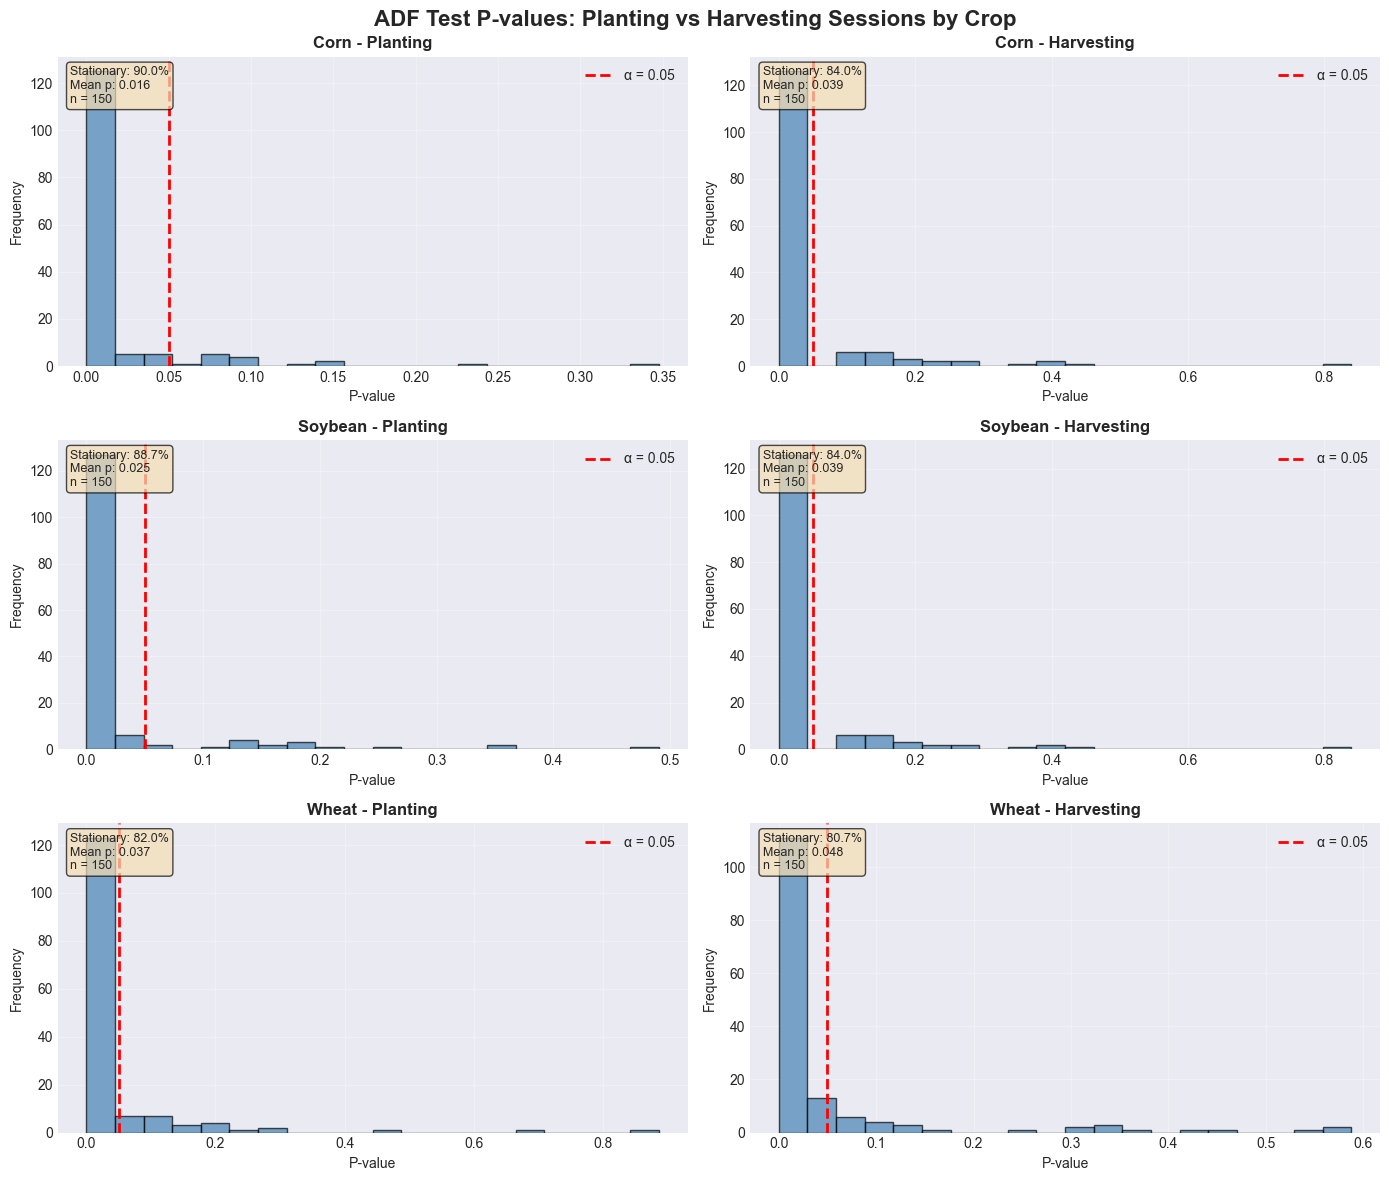

In [65]:
# Plot 1: P-value distribution by crop and session
fig, axes = plt.subplots(len(CROPS), 2, figsize=(14, 12))
fig.suptitle('ADF Test P-values: Planting vs Harvesting Sessions by Crop', fontsize=16, fontweight='bold')

for i, crop in enumerate(CROPS):
    crop_data = seasonal_df[seasonal_df['crop'] == crop]
    
    for j, session in enumerate(SESSIONS):
        ax = axes[i, j]
        session_data = crop_data[crop_data['session'] == session]
        
        if len(session_data) > 0:
            # Histogram
            ax.hist(session_data['p_value'].dropna(), bins=20, alpha=0.7, 
                   color='steelblue', edgecolor='black')
            
            # Add significance line
            ax.axvline(ALPHA, color='red', linestyle='--', linewidth=2, 
                      label=f'α = {ALPHA}')
            
            # Statistics
            stationary_pct = (session_data['stationary'] == 'Yes').sum() / len(session_data) * 100
            mean_p = session_data['p_value'].mean()
            
            ax.set_title(f"{crop.capitalize()} - {session.capitalize()}", 
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('P-value', fontsize=10)
            ax.set_ylabel('Frequency', fontsize=10)
            ax.legend(loc='upper right')
            ax.grid(True, alpha=0.3)
            
            # Add stats box
            stats_text = f"Stationary: {stationary_pct:.1f}%\nMean p: {mean_p:.3f}\nn = {len(session_data)}"
            ax.text(0.02, 0.97, stats_text, transform=ax.transAxes,
                   verticalalignment='top', horizontalalignment='left',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7), 
                   fontsize=9)

plt.tight_layout()
plt.show()

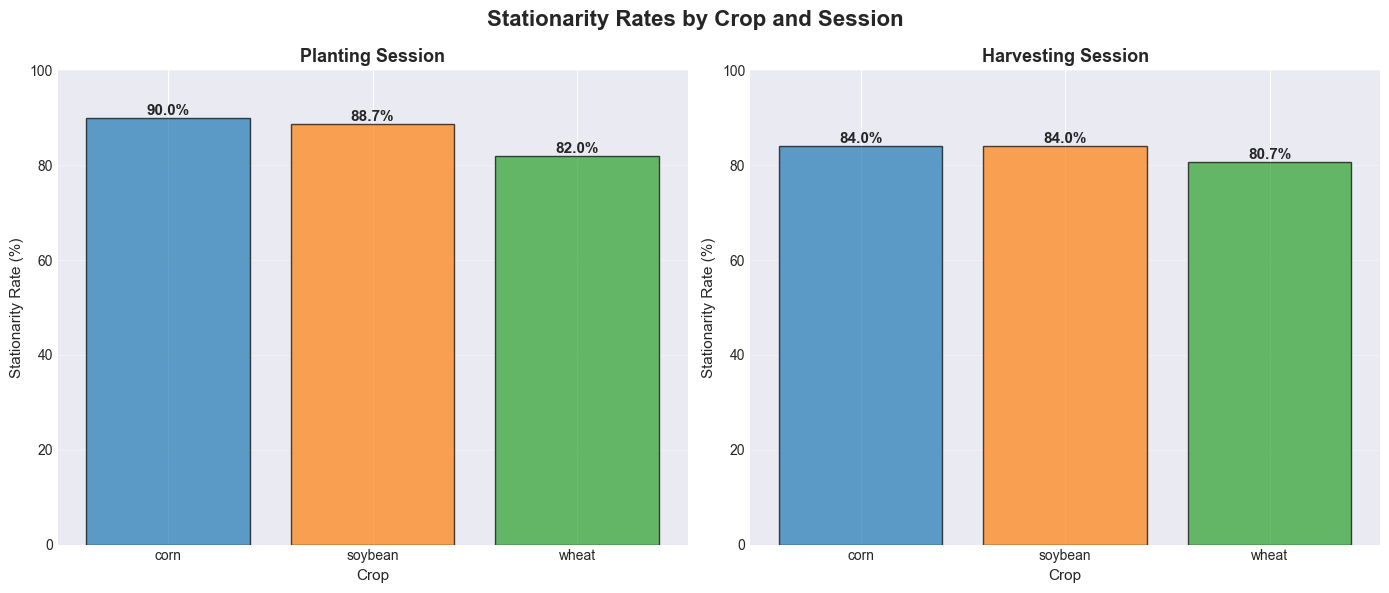

In [66]:
# Plot 2: Stationarity comparison across crops
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Stationarity Rates by Crop and Session', fontsize=16, fontweight='bold')

for j, session in enumerate(SESSIONS):
    ax = axes[j]
    
    session_data = seasonal_df[seasonal_df['session'] == session]
    
    # Calculate stationarity rates by crop
    rates = []
    for crop in CROPS:
        crop_session = session_data[session_data['crop'] == crop]
        if len(crop_session) > 0:
            rate = (crop_session['stationary'] == 'Yes').sum() / len(crop_session) * 100
            rates.append(rate)
        else:
            rates.append(0)
    
    # Bar plot
    bars = ax.bar(CROPS, rates, color=['#1f77b4', '#ff7f0e', '#2ca02c'], 
                   alpha=0.7, edgecolor='black')
    
    # Add value labels on bars
    for bar, rate in zip(bars, rates):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{rate:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_title(f"{session.capitalize()} Session", fontsize=13, fontweight='bold')
    ax.set_xlabel('Crop', fontsize=11)
    ax.set_ylabel('Stationarity Rate (%)', fontsize=11)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Plot 3: Heatmap of stationarity by crop, session, and variable
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Stationarity Rates by Crop, Session, and Climate Variable', 
             fontsize=16, fontweight='bold')

for j, session in enumerate(SESSIONS):
    ax = axes[j]
    
    # Create pivot table
    session_data = seasonal_df[seasonal_df['session'] == session]
    
    pivot_data = []
    for crop in CROPS:
        row = []
        for var in CLIMATE_VARS:
            subset = session_data[(session_data['crop'] == crop) & 
                                 (session_data['variable'] == var)]
            if len(subset) > 0:
                rate = (subset['stationary'] == 'Yes').sum() / len(subset) * 100
                row.append(rate)
            else:
                row.append(np.nan)
        pivot_data.append(row)
    
    pivot_df = pd.DataFrame(pivot_data, index=[c.capitalize() for c in CROPS], 
                           columns=CLIMATE_VARS)
    
    # Heatmap
    sns.heatmap(pivot_df, annot=True, fmt='.1f', cmap='RdYlGn', 
               vmin=0, vmax=100, cbar_kws={'label': 'Stationarity Rate (%)'},
               ax=ax, linewidths=0.5, linecolor='gray')
    
    ax.set_title(f"{session.capitalize()} Session", fontsize=13, fontweight='bold')
    ax.set_xlabel('Climate Variable', fontsize=11)
    ax.set_ylabel('Crop', fontsize=11)

plt.tight_layout()
plt.show()

## Export Results

In [19]:
# Save results to CSV
output_file = DATA_DIR / 'analysis' / 'adf_test_results.csv'
output_file.parent.mkdir(parents=True, exist_ok=True)

all_results.to_csv(output_file, index=False)
print(f"\nResults saved to: {output_file}")
print(f"Total series tested: {len(all_results)}")

# Save seasonal results
seasonal_output = DATA_DIR / 'analysis' / 'adf_seasonal_results.csv'
seasonal_df.to_csv(seasonal_output, index=False)
print(f"Seasonal results saved to: {seasonal_output}")
print(f"Total seasonal tests: {len(seasonal_df)}")

# Combined summary
print(f"\nResults saved to: {output_file}")
print(f"Total series tested: {len(all_results) + len(seasonal_df)}")


Results saved to: /Users/arshia/Projects/Papers/FinancialAI/Volf/data/analysis/adf_test_results.csv
Total series tested: 349
